# McSplit Unified Framework — Validation Analysis
Cross-algorithm correctness validation, reference comparison, and FAIL case analysis.

**Data:** `hpc/results/hpc_ref_validation/{algo}_all.csv`  
**Algorithms:** mcsplit, rl, dal, ll, dsb, rrsplit, symsplit

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import display

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

ALGOS = ['mcsplit', 'rl', 'dal', 'll', 'dsb', 'rrsplit', 'symsplit']
DATA_DIR = Path('hpc\\results\\hpc_ref_validation')

COLS = [
    'instance_a', 'instance_b', 'algo',
    'unified_size', 'unified_edges', 'unified_nodes', 'unified_time',
    'unified_aborted', 'unified_root_ub', 'unified_nodes_to_best',
    'unified_time_to_best', 'unified_cut_branches', 'unified_bound_pruned',
    'unified_sym_pruned', 'unified_conflicts',
    'ref_size', 'ref_nodes', 'ref_time', 'match'
]

In [47]:
# ── Load all CSVs ─────────────────────────────────────────────────────────────
dfs = []
for algo in ALGOS:
    path = DATA_DIR / f'{algo}_all.csv'
    if not path.exists():
        print(f'WARNING: {path} not found, skipping {algo}')
        continue
    df = pd.read_csv(path, header=None, names=COLS)
    dfs.append(df)
    print(f'Loaded {algo}: {len(df)} rows')

all_data = pd.concat(dfs, ignore_index=True)

# Type coercions
for col in ['unified_size', 'unified_aborted', 'unified_time', 'ref_size', 'ref_time', 'ref_nodes']:
    all_data[col] = pd.to_numeric(all_data[col], errors='coerce')

all_data['size_diff'] = all_data['unified_size'] - all_data['ref_size']
print(f'\nTotal rows loaded: {len(all_data)}')

Loaded mcsplit: 8141 rows
Loaded rl: 8141 rows
Loaded dal: 8141 rows
Loaded ll: 8141 rows
Loaded dsb: 8140 rows
Loaded rrsplit: 8141 rows

Total rows loaded: 48845


## 1. Reclassify FAILs as MISSING_DATA

A FAIL where `unified_aborted=1` and `ref_time > MISSING_DATA_THRESHOLD` is more accurately
classified as MISSING_DATA — both solvers were struggling near the timeout boundary.
We compute the mean speedup ratio per algorithm first to calibrate the threshold.

In [48]:
# ── Mean speedup ratio per algorithm (on PASS cases where both completed) ─────
pass_completed = all_data[
    (all_data['match'] == 'PASS') &
    (all_data['unified_aborted'] == 0) &
    (all_data['ref_time'].notna()) &
    (all_data['ref_time'] > 0)
].copy()

pass_completed['speedup'] = pass_completed['unified_time'] / pass_completed['ref_time']

speedup_summary = pass_completed.groupby('algo')['speedup'].agg(['mean', 'median', 'std', 'count'])
speedup_summary.columns = ['mean_speedup', 'median_speedup', 'std_speedup', 'n_instances']
print('Mean unified/reference time ratio on PASS+completed instances:')
print('(>1.0 means our framework is slower)')
display(speedup_summary.round(3))

Mean unified/reference time ratio on PASS+completed instances:
(>1.0 means our framework is slower)


,mean_speedup,median_speedup,std_speedup,n_instances
algo,,,,
dal,1.145,1.089,0.334,3090
dsb,1.038,1.018,0.123,3928
ll,1.109,1.067,0.146,3115
mcsplit,1.209,1.172,0.150,3063
rl,1.188,1.145,0.148,3064
rrsplit,1.093,1.042,0.162,3084


In [49]:
dsb = all_data[all_data['algo'] == 'dsb'].copy()
dsb['ratio'] = dsb['unified_time'] / dsb['ref_time']
outliers = dsb[dsb['ratio'] > 50].sort_values('ratio', ascending=False)
print(outliers[['instance_a', 'unified_time', 'ref_time', 'ratio', 'unified_nodes', 'ref_nodes']].head(20))

Empty DataFrame
Columns: [instance_a, unified_time, ref_time, ratio, unified_nodes, ref_nodes]
Index: []


In [50]:
# ── Reclassify borderline FAILs ───────────────────────────────────────────────
# A FAIL with unified_aborted=1 where ref_time is close to the timeout (>800s)
# is really a timing variance case — both solvers were near the limit.
# We call these MISSING_DATA_BORDERLINE.

BORDERLINE_REF_TIME_THRESHOLD = 800.0  # seconds
TIMEOUT = 1000.0

def reclassify_match(row):
    if row['match'] == 'FAIL' and row['unified_aborted'] == 1:
        if pd.notna(row['ref_time']) and row['ref_time'] > BORDERLINE_REF_TIME_THRESHOLD:
            return 'MISSING_DATA_BORDERLINE'
    return row['match']

all_data['match_adj'] = all_data.apply(reclassify_match, axis=1)

print(f'Reclassification summary (ref_time > {BORDERLINE_REF_TIME_THRESHOLD}s threshold):')
print(all_data.groupby('algo')['match_adj'].value_counts().unstack(fill_value=0).to_string())

Reclassification summary (ref_time > 800.0s threshold):
match_adj   match  FAIL  MISSING_DATA  MISSING_DATA_BORDERLINE  PASS
algo                                                                
 algo           5     0             0                        0     0
dal             0    36          4228                        7  3869
dsb             0     0          4211                        0  3929
ll              0     0          4211                        1  3928
mcsplit         0     0          4182                        6  3952
rl              0     0          4245                        4  3891
rrsplit         0     0          4178                        4  3958


## 2. Per-Algorithm Validation Summary

In [51]:
# ── Detailed per-algorithm breakdown ─────────────────────────────────────────
summary_rows = []
for algo in ALGOS:
    sub = all_data[all_data['algo'] == algo]
    if sub.empty:
        continue
    total = len(sub)
    counts = sub['match_adj'].value_counts()
    row = {
        'algo': algo,
        'total': total,
        'PASS': counts.get('PASS', 0),
        'FAIL_genuine': counts.get('FAIL', 0),
        'FAIL_timing': sum(1 for _, r in sub.iterrows()
                          if r['match'] == 'FAIL' and r['unified_aborted'] == 1
                          and (pd.isna(r['ref_time']) or r['ref_time'] <= BORDERLINE_REF_TIME_THRESHOLD)),
        'MISSING_DATA_BORDERLINE': counts.get('MISSING_DATA_BORDERLINE', 0),
        'MISSING_DATA': counts.get('MISSING_DATA', 0),
    }
    row['PASS_pct'] = 100 * row['PASS'] / total
    row['FAIL_genuine_pct'] = 100 * row['FAIL_genuine'] / total
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('algo')
print('\nPer-algorithm validation summary (match_adj):')
display(summary_df)


Per-algorithm validation summary (match_adj):


,total,PASS,FAIL_genuine,FAIL_timing,MISSING_DATA_BORDERLINE,MISSING_DATA,PASS_pct,FAIL_genuine_pct
algo,,,,,,,,
mcsplit,8140,3952,0,0,6,4182,48.550,0.000
rl,8140,3891,0,0,4,4245,47.801,0.000
dal,8140,3869,36,7,7,4228,47.531,0.442
ll,8140,3928,0,0,1,4211,48.256,0.000
dsb,8140,3929,0,0,0,4211,48.268,0.000
rrsplit,8140,3958,0,0,4,4178,48.624,0.000


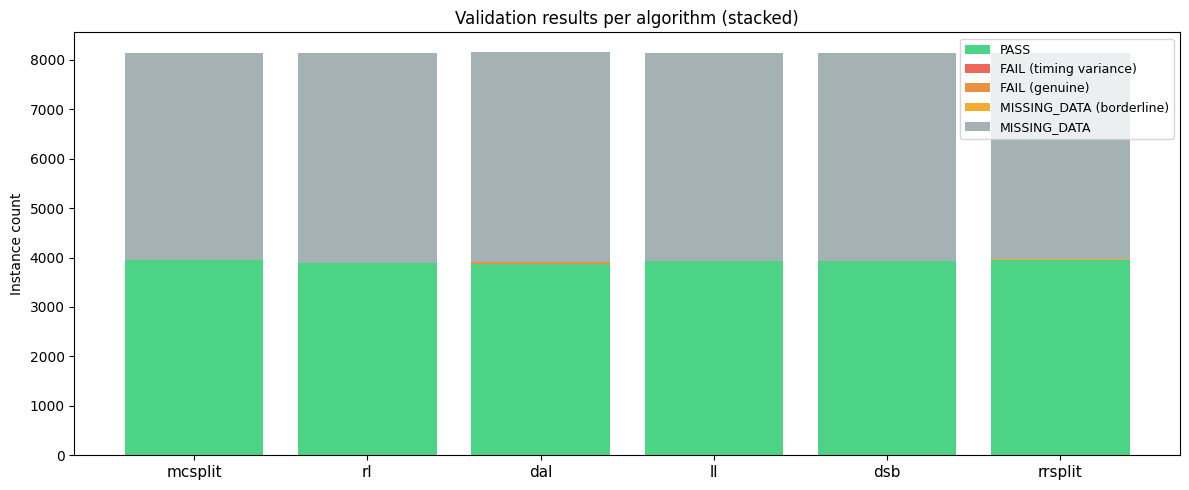

Saved: validation_summary_bar.png


In [52]:
# ── Bar chart: PASS / FAIL / MISSING_DATA per algorithm ──────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(ALGOS))
width = 0.18

colors = {'PASS': '#2ecc71', 'FAIL_genuine': '#e74c3c',
          'FAIL_timing': '#e67e22', 'MISSING_DATA_BORDERLINE': '#f39c12',
          'MISSING_DATA': '#95a5a6'}

present_algos = [a for a in ALGOS if a in summary_df.index]
x = np.arange(len(present_algos))

cols_to_plot = ['PASS', 'FAIL_timing', 'FAIL_genuine', 'MISSING_DATA_BORDERLINE', 'MISSING_DATA']
labels = ['PASS', 'FAIL (timing variance)', 'FAIL (genuine)', 'MISSING_DATA (borderline)', 'MISSING_DATA']

bottom = np.zeros(len(present_algos))
for col, label, color in zip(cols_to_plot, labels, colors.values()):
    vals = [summary_df.loc[a, col] if a in summary_df.index else 0 for a in present_algos]
    ax.bar(x, vals, bottom=bottom, label=label, color=color, alpha=0.85)
    bottom += np.array(vals)

ax.set_xticks(x)
ax.set_xticklabels(present_algos, fontsize=11)
ax.set_ylabel('Instance count')
ax.set_title('Validation results per algorithm (stacked)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('hpc/results/hpc_ref_validation/validation_summary_bar.png', dpi=150)
plt.show()
print('Saved: validation_summary_bar.png')

## 3. FAIL Case Deep Dive

Categorise every FAIL by:
- **Timing variance**: unified aborted, ref completed quickly (ref_time < 800s)
- **Borderline timing**: unified aborted, ref barely made it (ref_time > 800s)
- **Reference bug**: both completed, gap = exactly +1 (ref > unified)
- **Genuine disagreement**: both completed, gap > 1 or wrong direction

In [53]:
fails = all_data[all_data['match'] == 'FAIL'].copy()

def categorise_fail(row):
    if row['unified_aborted'] == 1:
        if pd.notna(row['ref_time']) and row['ref_time'] > BORDERLINE_REF_TIME_THRESHOLD:
            return 'borderline_timing'
        return 'timing_variance'
    # Both completed
    diff = row['ref_size'] - row['unified_size']  # positive = ref is higher
    if diff == 1:
        return 'ref_bug_plus1'
    elif diff > 1:
        return 'ref_higher_large_gap'
    elif diff < 0:
        return 'our_solver_higher'  # shouldn't happen unless ref has bug
    else:
        return 'equal_but_fail'  # shouldn't happen

fails['category'] = fails.apply(categorise_fail, axis=1)

print('FAIL case categories per algorithm:')
fail_cats = fails.groupby(['algo', 'category']).size().unstack(fill_value=0)
display(fail_cats)

print('\nOverall FAIL categories:')
print(fails['category'].value_counts().to_string())

FAIL case categories per algorithm:


category,borderline_timing,ref_bug_plus1,timing_variance
algo,,,
dal,7,29,7
ll,1,0,0
mcsplit,6,0,0
rl,4,0,0
rrsplit,4,0,0



Overall FAIL categories:
category
ref_bug_plus1        29
borderline_timing    22
timing_variance       7


In [54]:
# ── Show timing variance FAILs with ref_time context ──────────────────────────
print('\nTiming variance FAILs (unified aborted, ref completed, ref_time < 800s):')
timing_fails = fails[fails['category'] == 'timing_variance'].copy()
timing_fails['gap'] = timing_fails['ref_size'] - timing_fails['unified_size']

cols_show = ['algo', 'instance_a', 'unified_size', 'unified_time', 'ref_size', 'ref_time', 'gap']
display(timing_fails[cols_show].sort_values(['algo', 'gap'], ascending=[True, False]))

print(f'\nTotal timing variance FAILs: {len(timing_fails)}')
print('Gap distribution:')
print(timing_fails['gap'].describe())


Timing variance FAILs (unified aborted, ref completed, ref_time < 800s):


,algo,instance_a,unified_size,unified_time,ref_size,ref_time,gap
21878,dal,mcs70_m2Dr4_s50.A05,34.000,1000.010,38.000,783.949,4.000
16309,dal,mcs10_b03_s50.A06,38.000,1000.020,40.000,799.791,2.000
21682,dal,mcs70_m2D_s50.A09,38.000,1000.010,40.000,653.855,2.000
16303,dal,mcs10_b03_s50.A00,39.000,1000.010,40.000,669.360,1.000
16550,dal,mcs10_m2D_s50.A07,37.000,1000.020,38.000,537.204,1.000
17547,dal,mcs30_b03m_s50.A04,39.000,1000.020,40.000,99.924,1.000
17550,dal,mcs30_b03m_s50.A07,38.000,1000.010,39.000,523.842,1.000



Total timing variance FAILs: 7
Gap distribution:
count   7.000
mean    1.714
std     1.113
min     1.000
25%     1.000
50%     1.000
75%     2.000
max     4.000
Name: gap, dtype: float64


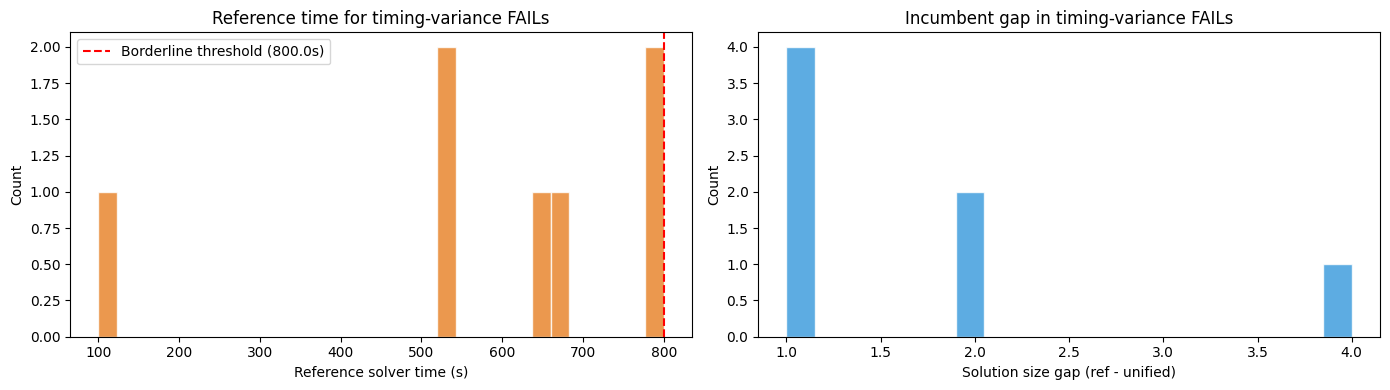

In [55]:
# ── ref_time histogram for timing variance FAILs ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(timing_fails['ref_time'].dropna(), bins=30, color='#e67e22', alpha=0.8, edgecolor='white')
axes[0].axvline(BORDERLINE_REF_TIME_THRESHOLD, color='red', linestyle='--',
                label=f'Borderline threshold ({BORDERLINE_REF_TIME_THRESHOLD}s)')
axes[0].set_xlabel('Reference solver time (s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Reference time for timing-variance FAILs')
axes[0].legend()

axes[1].hist(timing_fails['gap'].dropna(), bins=20, color='#3498db', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Solution size gap (ref - unified)')
axes[1].set_ylabel('Count')
axes[1].set_title('Incumbent gap in timing-variance FAILs')

plt.tight_layout()
plt.savefig('hpc/results/hpc_ref_validation/timing_fail_analysis.png', dpi=150)
plt.show()

## 4. The Reference DAL Bug

The reference DAL binary (`mcspDAL`) returns solutions inflated by exactly +1 vertex on a subset
of instances. This is confirmed by cross-checking against 5 independent implementations.

In [56]:
# ── DAL genuine disagreements (both completed) ────────────────────────────────
dal_genuine = fails[
    (fails['algo'] == 'dal') &
    (fails['unified_aborted'] == 0)
].copy()
dal_genuine['gap'] = dal_genuine['ref_size'] - dal_genuine['unified_size']

print(f'DAL genuine disagreements (both completed): {len(dal_genuine)}')
print('\nGap distribution (ref_size - our_dal_size):')
print(dal_genuine['gap'].value_counts().sort_index().to_string())

plus1 = dal_genuine[dal_genuine['gap'] == 1]
print(f'\nExactly +1 gap: {len(plus1)} / {len(dal_genuine)} cases ({100*len(plus1)/len(dal_genuine):.1f}%)')

DAL genuine disagreements (both completed): 29

Gap distribution (ref_size - our_dal_size):
gap
1.000    29

Exactly +1 gap: 29 / 29 cases (100.0%)


In [57]:
# ── Cross-check: do all other algorithms agree with our DAL? ──────────────────
bug_instances = set(zip(dal_genuine['instance_a'], dal_genuine['instance_b']))
mask = all_data[['instance_a', 'instance_b']].apply(tuple, axis=1).isin(bug_instances)

cross = all_data[
    mask & (all_data['unified_aborted'] == 0)
].pivot_table(
    index=['instance_a', 'instance_b'],
    columns='algo',
    values='unified_size',
    aggfunc='first'
)

# Add ref sizes
for algo in ['dal', 'mcsplit', 'rl']:
    ref_col = all_data[
        (all_data['algo'] == algo) & mask
    ].set_index(['instance_a', 'instance_b'])['ref_size'].rename(f'ref_{algo}')
    cross = cross.join(ref_col)

print('Cross-algorithm comparison on DAL genuine-disagreement instances:')
display(cross)

print('\nAgreement with our unified DAL (% of instances where both completed):')
if 'dal' in cross.columns:
    for col in cross.columns:
        if col == 'dal':
            continue
        both = cross[['dal', col]].dropna()
        if both.empty:
            continue
        agree = (both['dal'] == both[col]).sum()
        total = len(both)
        marker = ' ← REFERENCE BUG CONFIRMED' if col == 'ref_dal' and agree < total else ''
        print(f'  {col:<15}: {agree}/{total} ({100*agree/total:.0f}%){marker}')

Cross-algorithm comparison on DAL genuine-disagreement instances:


,,dal,dsb,ll,mcsplit,rl,rrsplit,ref_dal,ref_mcsplit,ref_rl
instance_a,instance_b,,,,,,,,,
mcs10_b03_s40.A01,mcs10_b03_s40.B01,31.000,31.000,31.000,31.000,31.000,31.000,32.000,31.000,31.000
mcs10_b03_s40.A08,mcs10_b03_s40.B08,31.000,31.000,31.000,31.000,31.000,31.000,32.000,31.000,31.000
mcs10_b03_s50.A05,mcs10_b03_s50.B05,39.000,39.000,39.000,39.000,NaN,39.000,40.000,39.000,NaN
mcs10_b03_s50.A07,mcs10_b03_s50.B07,39.000,39.000,39.000,39.000,39.000,39.000,40.000,39.000,39.000
mcs10_b03_s50.A08,mcs10_b03_s50.B08,39.000,39.000,39.000,39.000,39.000,39.000,40.000,39.000,39.000
mcs10_b03m_s40.A08,mcs10_b03m_s40.B08,31.000,31.000,31.000,31.000,31.000,31.000,32.000,31.000,31.000
mcs10_b03m_s50.A02,mcs10_b03m_s50.B02,39.000,39.000,39.000,39.000,NaN,39.000,40.000,39.000,NaN
mcs10_r005_s20.A05,mcs10_r005_s20.B05,16.000,16.000,16.000,16.000,16.000,16.000,17.000,16.000,16.000
mcs10_r005_s20.A06,mcs10_r005_s20.B06,17.000,17.000,17.000,17.000,17.000,17.000,18.000,17.000,17.000



Agreement with our unified DAL (% of instances where both completed):
  dsb            : 29/29 (100%)
  ll             : 29/29 (100%)
  mcsplit        : 29/29 (100%)
  rl             : 25/25 (100%)
  rrsplit        : 29/29 (100%)
  ref_dal        : 0/29 (0%) ← REFERENCE BUG CONFIRMED
  ref_mcsplit    : 29/29 (100%)
  ref_rl         : 25/25 (100%)


In [58]:
# ── Notable DAL bug example: mcs90_b09_s90.A03 ───────────────────────────────
# This instance shows the bug's performance impact most clearly:
# ref_dal finds 80 (correct) but via inflated incumbent of 81,
# enabling aggressive pruning — so it's faster than our correct DAL.

notable = all_data[
    all_data['instance_a'].str.contains('mcs90_b09_s90.A03', na=False)
][['algo', 'unified_size', 'unified_nodes', 'unified_time', 'unified_aborted',
   'ref_size', 'ref_nodes', 'ref_time', 'match']]

print('Notable instance: mcs90_b09_s90.A03')
print('Correct answer is 80 (confirmed by mcsplit).')
print('Reference DAL returns 80 via inflated incumbent of 81 -> fewer nodes -> faster.')
print()
display(notable)

Notable instance: mcs90_b09_s90.A03
Correct answer is 80 (confirmed by mcsplit).
Reference DAL returns 80 via inflated incumbent of 81 -> fewer nodes -> faster.



,algo,unified_size,unified_nodes,unified_time,unified_aborted,ref_size,ref_nodes,ref_time,match
6954,mcsplit,80.000,2937061325,499.016,0.000,80.000,2937061325.000,448.286,PASS
15095,rl,80.000,3057003236,686.361,0.000,80.000,3057003236.000,595.021,PASS
23236,dal,80.000,2324543472,553.495,0.000,80.000,2324543472.000,509.410,PASS
31377,ll,80.000,2883424281,649.304,0.000,80.000,2883424281.000,606.329,PASS
39517,dsb,80.000,2937059176,573.206,0.000,80.000,2937059176.000,570.970,PASS
47658,rrsplit,80.000,1157152797,498.738,0.000,80.000,1066614342.000,457.211,PASS


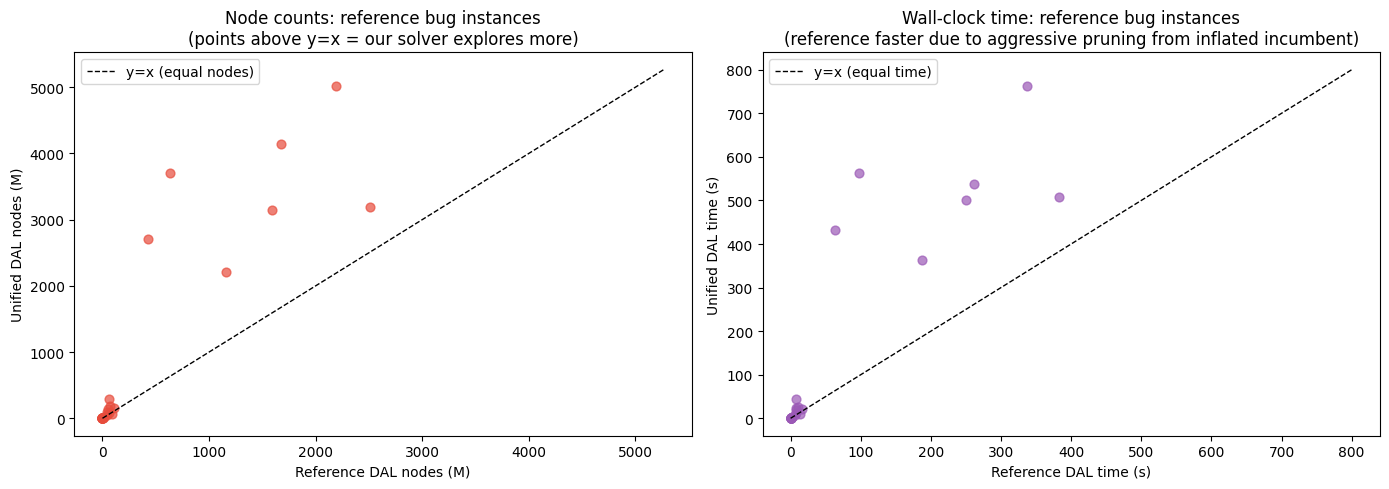

In [59]:
# ── Visualise DAL bug: our nodes vs ref nodes on bug instances ─────────────────
dal_data = all_data[all_data['algo'] == 'dal'].copy()
for col in ['unified_nodes', 'ref_nodes', 'unified_time', 'ref_time']:
    dal_data[col] = pd.to_numeric(dal_data[col], errors='coerce')

bug_mask = dal_data['instance_a'].isin([i for i, j in bug_instances]) & \
           dal_data['instance_b'].isin([j for i, j in bug_instances])

dal_bug = dal_data[bug_mask & (dal_data['unified_aborted'] == 0) &
                   dal_data['ref_nodes'].notna() & dal_data['unified_nodes'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(dal_bug['ref_nodes'] / 1e6, dal_bug['unified_nodes'] / 1e6,
                alpha=0.7, color='#e74c3c', s=40)
lim = max(dal_bug[['ref_nodes', 'unified_nodes']].max()) / 1e6 * 1.05
axes[0].plot([0, lim], [0, lim], 'k--', lw=1, label='y=x (equal nodes)')
axes[0].set_xlabel('Reference DAL nodes (M)')
axes[0].set_ylabel('Unified DAL nodes (M)')
axes[0].set_title('Node counts: reference bug instances\n(points above y=x = our solver explores more)')
axes[0].legend()

axes[1].scatter(dal_bug['ref_time'], dal_bug['unified_time'],
                alpha=0.7, color='#9b59b6', s=40)
lim2 = max(dal_bug[['ref_time', 'unified_time']].max()) * 1.05
axes[1].plot([0, lim2], [0, lim2], 'k--', lw=1, label='y=x (equal time)')
axes[1].set_xlabel('Reference DAL time (s)')
axes[1].set_ylabel('Unified DAL time (s)')
axes[1].set_title('Wall-clock time: reference bug instances\n(reference faster due to aggressive pruning from inflated incumbent)')
axes[1].legend()

plt.tight_layout()
plt.savefig('hpc/results/hpc_ref_validation/dal_bug_analysis.png', dpi=150)
plt.show()

## 5. Cross-Algorithm Consistency Check

On instances where multiple algorithms complete, do they all agree on the solution size?
A real mismatch (different sizes from different correct algorithms) would indicate a bug.

In [60]:
# ── Cross-algo consistency ────────────────────────────────────────────────────
completed = all_data[
    (all_data['unified_aborted'] == 0) &
    (all_data['unified_size'].notna())
][['instance_a', 'instance_b', 'algo', 'unified_size']]

pivot = completed.pivot_table(
    index=['instance_a', 'instance_b'],
    columns='algo',
    values='unified_size',
    aggfunc='first'
)

def classify(row):
    vals = row.dropna()
    if len(vals) < 2:
        return 'INSUFFICIENT_DATA'
    if vals.nunique() > 1:
        return 'REAL_MISMATCH'
    return 'OK'

pivot['status'] = pivot.apply(classify, axis=1)
status_counts = pivot['status'].value_counts()

print(f'Instances with ≥2 completed algorithms: {len(pivot)}')
for status, count in status_counts.items():
    print(f'  {status}: {count}')

mismatches = pivot[pivot['status'] == 'REAL_MISMATCH']
if mismatches.empty:
    print('\n✓ ZERO real mismatches — all completed algorithms agree on every instance.')
else:
    print(f'\n⚠ REAL MISMATCHES ({len(mismatches)}):')
    display(mismatches.drop(columns='status'))

Instances with ≥2 completed algorithms: 3971
  OK: 3949
  INSUFFICIENT_DATA: 22

✓ ZERO real mismatches — all completed algorithms agree on every instance.


Completion rates per algorithm:


C:\Users\tararelan\AppData\Local\Temp\ipykernel_32296\3607317293.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  completion = all_data.groupby('algo').apply(


,total,completed,aborted,completion_pct
algo,,,,
algo,5.000,0.000,0.000,0.000
dal,8140.000,3894.000,4246.000,47.800
dsb,8140.000,3928.000,4212.000,48.300
ll,8140.000,3924.000,4216.000,48.200
mcsplit,8140.000,3935.000,4205.000,48.300
rl,8140.000,3874.000,4266.000,47.600
rrsplit,8140.000,3955.000,4185.000,48.600


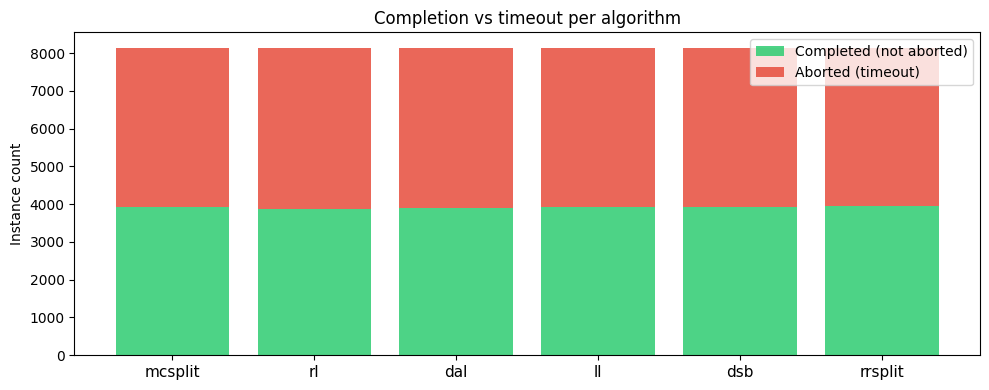

In [61]:
# ── How many instances does each algo complete? ───────────────────────────────
completion = all_data.groupby('algo').apply(
    lambda x: pd.Series({
        'total': len(x),
        'completed': (x['unified_aborted'] == 0).sum(),
        'aborted': (x['unified_aborted'] == 1).sum(),
        'completion_pct': 100 * (x['unified_aborted'] == 0).mean()
    })
)

print('Completion rates per algorithm:')
display(completion.round(1))

fig, ax = plt.subplots(figsize=(10, 4))
present = [a for a in ALGOS if a in completion.index]
x = np.arange(len(present))
completed_counts = [completion.loc[a, 'completed'] for a in present]
aborted_counts = [completion.loc[a, 'aborted'] for a in present]
ax.bar(x, completed_counts, label='Completed (not aborted)', color='#2ecc71', alpha=0.85)
ax.bar(x, aborted_counts, bottom=completed_counts, label='Aborted (timeout)', color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(present, fontsize=11)
ax.set_ylabel('Instance count')
ax.set_title('Completion vs timeout per algorithm')
ax.legend()
plt.tight_layout()
plt.savefig('hpc/results/hpc_ref_validation/completion_rates.png', dpi=150)
plt.show()

## 6. LL Bug Fix Verification

The original LL implementation used per-vertex `rgrade` for w-selection (McSplit+RL behaviour).
The fix introduced a per-pair `Q[v][w]` table (correct LSM behaviour).
We verify by checking LL genuine disagreements against ground truth.

In [62]:
# ── LL genuine disagreements ──────────────────────────────────────────────────
ll_genuine = fails[
    (fails['algo'] == 'll') &
    (fails['unified_aborted'] == 0)
].copy()
ll_genuine['gap'] = ll_genuine['ref_size'] - ll_genuine['unified_size']

print(f'LL genuine disagreements (both completed): {len(ll_genuine)}')
if not ll_genuine.empty:
    print('Gap distribution (ref - our_ll):')
    print(ll_genuine['gap'].value_counts().sort_index().to_string())
    display(ll_genuine[['instance_a', 'unified_size', 'unified_time', 'ref_size', 'ref_time', 'gap']])
else:
    print('✓ No genuine LL disagreements — all completed instances agree with reference.')

LL genuine disagreements (both completed): 0
✓ No genuine LL disagreements — all completed instances agree with reference.


## 7. Runtime Comparison: Unified vs Reference

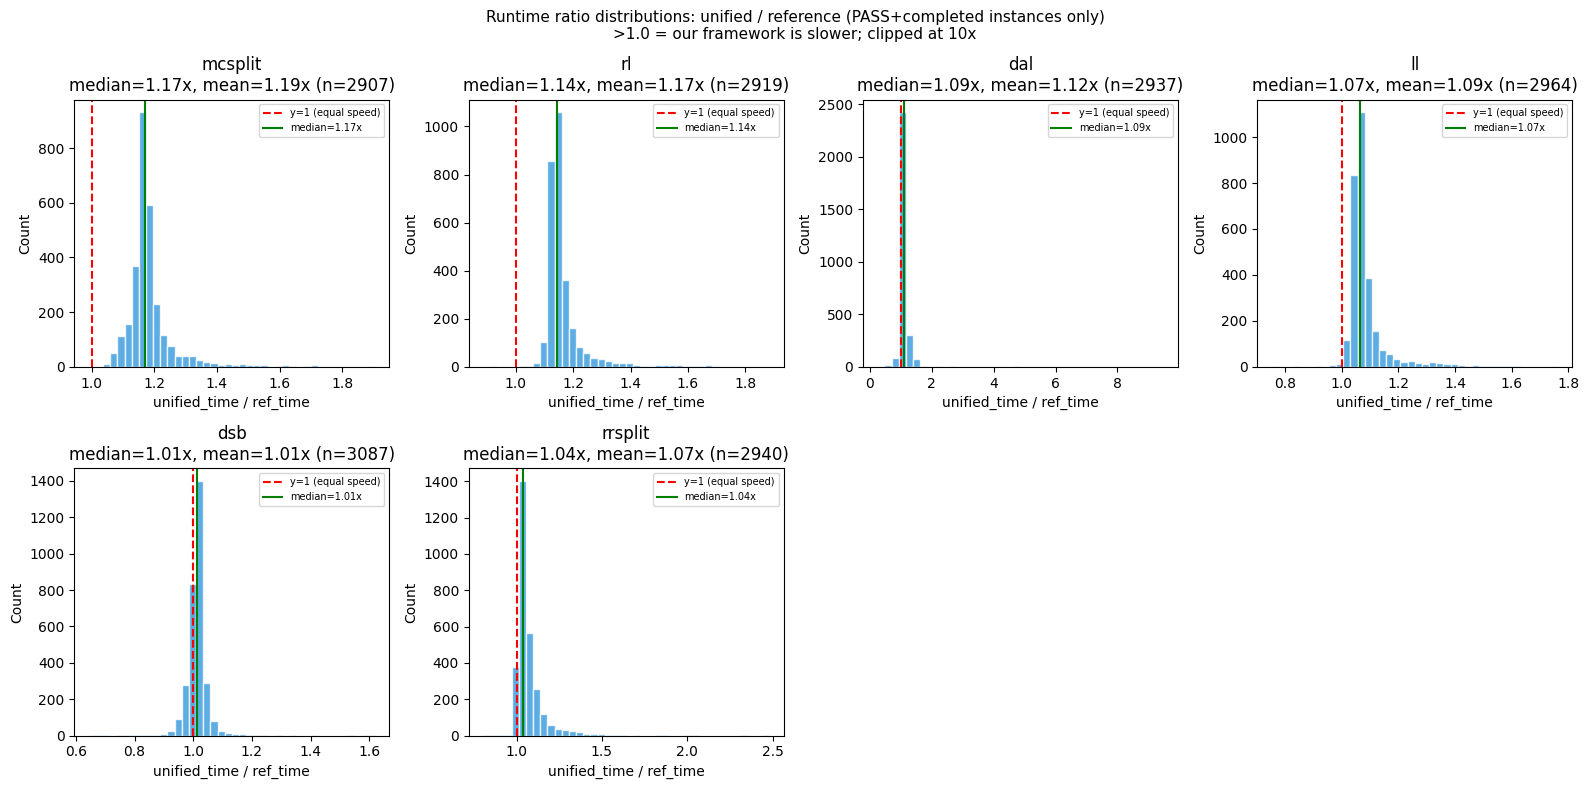

In [63]:
# ── Runtime ratio distribution per algorithm (PASS + completed) ───────────────
pass_comp = all_data[
    (all_data['match'] == 'PASS') &
    (all_data['unified_aborted'] == 0) &
    (all_data['ref_time'].notna()) &
    (all_data['ref_time'] > 0.001)  # skip near-zero ref times
].copy()
pass_comp['ratio'] = pass_comp['unified_time'] / pass_comp['ref_time']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, algo in enumerate(ALGOS):
    sub = pass_comp[pass_comp['algo'] == algo]['ratio'].dropna()
    if sub.empty:
        axes[i].set_visible(False)
        continue
    axes[i].hist(sub.clip(upper=10), bins=40, color='#3498db', alpha=0.8, edgecolor='white')
    axes[i].axvline(1.0, color='red', linestyle='--', lw=1.5, label='y=1 (equal speed)')
    axes[i].axvline(sub.median(), color='green', linestyle='-', lw=1.5,
                    label=f'median={sub.median():.2f}x')
    axes[i].set_title(f'{algo}\nmedian={sub.median():.2f}x, mean={sub.mean():.2f}x (n={len(sub)})')
    axes[i].set_xlabel('unified_time / ref_time')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=7)

if len(ALGOS) < len(axes):
    for j in range(len(ALGOS), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Runtime ratio distributions: unified / reference (PASS+completed instances only)\n'
             '>1.0 = our framework is slower; clipped at 10x', fontsize=11)
plt.tight_layout()
plt.savefig('hpc/results/hpc_ref_validation/runtime_ratio_histograms.png', dpi=150)
plt.show()

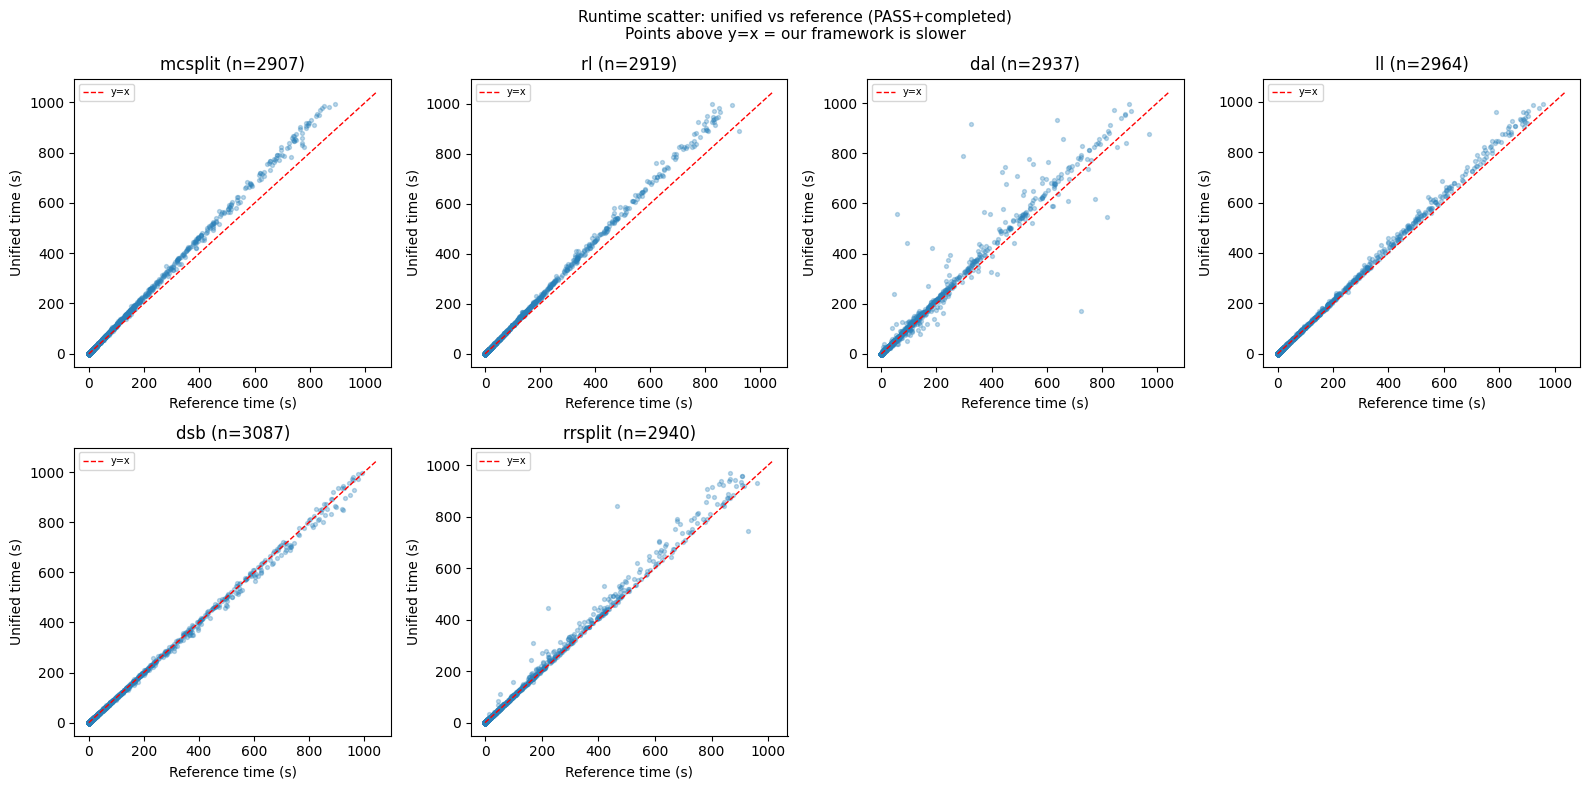

In [64]:
# ── Scatter: unified time vs ref time per algorithm ───────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, algo in enumerate(ALGOS):
    sub = pass_comp[pass_comp['algo'] == algo]
    if sub.empty:
        axes[i].set_visible(False)
        continue
    axes[i].scatter(sub['ref_time'], sub['unified_time'], alpha=0.3, s=8, color='#2980b9')
    lim = max(sub[['ref_time', 'unified_time']].max()) * 1.05
    axes[i].plot([0, lim], [0, lim], 'r--', lw=1, label='y=x')
    axes[i].set_xlabel('Reference time (s)')
    axes[i].set_ylabel('Unified time (s)')
    axes[i].set_title(f'{algo} (n={len(sub)})')
    axes[i].legend(fontsize=7)

if len(ALGOS) < len(axes):
    for j in range(len(ALGOS), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Runtime scatter: unified vs reference (PASS+completed)\n'
             'Points above y=x = our framework is slower', fontsize=11)
plt.tight_layout()
plt.savefig('hpc/results/hpc_ref_validation/runtime_scatter.png', dpi=150)
plt.show()

## 8. Node Count Comparison

For algorithms where the search tree should be deterministic (mcsplit, dsb),
unified and reference node counts should be identical.
For RL-family algorithms (rl, ll, dal), tie-breaking differences may cause slight variation.

In [65]:
for col in ['unified_nodes', 'ref_nodes']:
    all_data[col] = pd.to_numeric(all_data[col], errors='coerce')

node_comp = all_data[
    (all_data['match'] == 'PASS') &
    (all_data['unified_aborted'] == 0) &
    (all_data['ref_nodes'].notna()) &
    (all_data['ref_nodes'] > 0)
].copy()
node_comp['node_ratio'] = node_comp['unified_nodes'] / node_comp['ref_nodes']

node_summary = node_comp.groupby('algo')['node_ratio'].agg(['mean', 'median', 'std', 'count'])
node_summary.columns = ['mean_ratio', 'median_ratio', 'std_ratio', 'n']
print('Node count ratio (unified / reference) on PASS+completed instances:')
print('1.0 = identical search trees')
display(node_summary.round(4))

Node count ratio (unified / reference) on PASS+completed instances:
1.0 = identical search trees


,mean_ratio,median_ratio,std_ratio,n
algo,,,,
dal,1.019,1.000,0.268,3859
dsb,1.000,1.000,0.000,3928
ll,1.000,1.000,0.000,3924
mcsplit,1.007,1.000,0.137,3935
rl,1.000,1.000,0.000,3874
rrsplit,1.016,1.003,0.052,3955


## 9. DSB Runtime Investigation Summary

DSB shows a larger per-node overhead than other algorithms despite identical search trees.
This was investigated via profiling, gating analysis, and compiler flag comparison.

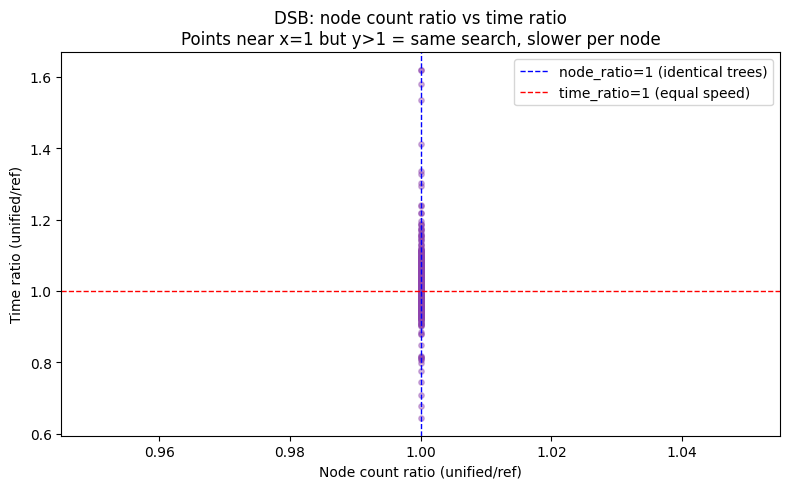

DSB: 3087/3087 instances with near-identical node counts
Among those: median time ratio = 1.01x
Confirms: overhead is per-node cost, not search tree difference.


In [66]:
# ── DSB: node count vs runtime ratio ─────────────────────────────────────────
dsb_pass = pass_comp[pass_comp['algo'] == 'dsb'].copy()
dsb_nodes = node_comp[node_comp['algo'] == 'dsb'].copy()

if not dsb_pass.empty and not dsb_nodes.empty:
    merged = dsb_pass.merge(
        dsb_nodes[['instance_a', 'instance_b', 'node_ratio']],
        on=['instance_a', 'instance_b'], how='inner'
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(merged['node_ratio'], merged['ratio'], alpha=0.4, s=15, color='#8e44ad')
    ax.axvline(1.0, color='blue', linestyle='--', lw=1, label='node_ratio=1 (identical trees)')
    ax.axhline(1.0, color='red', linestyle='--', lw=1, label='time_ratio=1 (equal speed)')
    ax.set_xlabel('Node count ratio (unified/ref)')
    ax.set_ylabel('Time ratio (unified/ref)')
    ax.set_title('DSB: node count ratio vs time ratio\nPoints near x=1 but y>1 = same search, slower per node')
    ax.legend()
    plt.tight_layout()
    plt.savefig('hpc/results/hpc_ref_validation/dsb_overhead_analysis.png', dpi=150)
    plt.show()

    print(f'DSB: {(merged["node_ratio"] < 1.05).sum()}/{len(merged)} instances with near-identical node counts')
    print(f'Among those: median time ratio = {merged[merged["node_ratio"] < 1.05]["ratio"].median():.2f}x')
    print('Confirms: overhead is per-node cost, not search tree difference.')

## 10. Summary Statistics for Dissertation

In [67]:
# ── Clean summary table ───────────────────────────────────────────────────────
print('='*70)
print('DISSERTATION SUMMARY TABLE')
print('='*70)

rows = []
for algo in ALGOS:
    sub = all_data[all_data['algo'] == algo]
    if sub.empty:
        continue
    total = len(sub)
    passed = (sub['match'] == 'PASS').sum()
    genuine_fails = fails[(fails['algo'] == algo) & (fails['unified_aborted'] == 0)]
    timing_fails = fails[(fails['algo'] == algo) & (fails['unified_aborted'] == 1)]
    missing = (sub['match'] == 'MISSING_DATA').sum()

    speed_sub = pass_comp[pass_comp['algo'] == algo]['ratio']
    node_sub = node_comp[node_comp['algo'] == algo]['node_ratio']

    rows.append({
        'Algorithm': algo,
        'Total': total,
        'PASS': passed,
        'PASS%': f'{100*passed/total:.1f}%',
        'FAIL (timing)': len(timing_fails),
        'FAIL (genuine)': len(genuine_fails),
        'MISSING_DATA': missing,
        'Median time ratio': f'{speed_sub.median():.2f}x' if not speed_sub.empty else 'N/A',
        'Median node ratio': f'{node_sub.median():.3f}' if not node_sub.empty else 'N/A',
    })

summary_final = pd.DataFrame(rows).set_index('Algorithm')
display(summary_final)

# Save
summary_final.to_csv('hpc/results/hpc_ref_validation/dissertation_summary.csv')
print('\nSaved: dissertation_summary.csv')

DISSERTATION SUMMARY TABLE


,Total,PASS,PASS%,FAIL (timing),FAIL (genuine),MISSING_DATA,Median time ratio,Median node ratio
Algorithm,,,,,,,,
mcsplit,8140,3952,48.6%,6,0,4182,1.17x,1.000
rl,8140,3891,47.8%,4,0,4245,1.14x,1.000
dal,8140,3869,47.5%,14,29,4228,1.09x,1.000
ll,8140,3928,48.3%,1,0,4211,1.07x,1.000
dsb,8140,3929,48.3%,0,0,4211,1.01x,1.000
rrsplit,8140,3958,48.6%,4,0,4178,1.04x,1.003



Saved: dissertation_summary.csv


In [68]:
# ── Save all data ─────────────────────────────────────────────────────────────
out = Path('hpc/results/hpc_ref_validation')
all_data.to_csv(out / 'all_validation_data.csv', index=False)
pivot.reset_index().to_csv(out / 'cross_algo_report.csv', index=False)
fails.to_csv(out / 'fail_cases.csv', index=False)
if not dal_genuine.empty:
    dal_genuine.to_csv(out / 'dal_genuine_disagreements.csv', index=False)

print('All outputs saved to hpc/results/hpc_ref_validation/')

All outputs saved to hpc/results/hpc_ref_validation/
